<div style="text-align:center;">

<h1 style="color:#4aa3ff;">📱 SMS Phishing Detection using Machine Learning</h1>

<p style="color:lightgray; font-size:18px;">
Intelligent detection of phishing messages using text-based analysis and machine learning
</p>

<p style="color:lightgray; font-size:16px;">
Comparative evaluation of multiple models to identify the most accurate solution
</p>

<hr>

</div>

<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">1️⃣ IMPORTING REQUIRED LIBRARIES</h2>

<p style="color:lightgray;">
Loading essential libraries for data processing, model training, and evaluation
</p>

<hr>

</div>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">2️⃣ DATA LOADING & OVERVIEW</h2>

<p style="color:lightgray;">
Loading and exploring combined SMS datasets for phishing (smishing) detection
</p>

<p style="color:lightgray; font-size:14px;">
📂 Dataset Sources: 
<a href="https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset" target="_blank" style="color:#4aa3ff;">
SMS Spam Collection Dataset
</a> 
& 
<a href="https://www.kaggle.com/datasets/fadlifatih/sms-phishing-dataset" target="_blank" style="color:#4aa3ff;">
SMS Phishing Dataset
</a>
</p>

<hr>

</div>

In [2]:
df = pd.read_csv("final_sms_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (6808, 2)


,label,message
0,0,Oh oh... Wasted... Den muz chiong on sat n sun...
1,0,Super msg da:)nalla timing.
2,0,Was doing my test earlier. I appreciate you. W...
3,1,Dorothy@kiefer.com (Bank of Granite issues Str...
4,0,"Ooh, 4got, i'm gonna start belly dancing in mo..."


<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">3️⃣ DATA CLEANING & PREPROCESSING</h2>

<p style="color:lightgray;">
Removing duplicates, handling missing values, and preparing clean text data
</p>

<hr>

</div>

In [3]:
# Drop missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

# Check class balance
print(df['label'].value_counts())

label
0    5305
1    1269
Name: count, dtype: int64


<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">4️⃣ TEXT FEATURE EXTRACTION (TF-IDF)</h2>

<p style="color:lightgray;">
Converting SMS text into numerical features using TF-IDF vectorization
</p>

<hr>

</div>

In [4]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X = tfidf.fit_transform(df['message']).toarray()
y = df['label']

<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">5️⃣ TRAIN-TEST DATA SPLITTING</h2>

<p style="color:lightgray;">
Dividing data into training and testing sets for unbiased evaluation
</p>

<hr>

</div>

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">6️⃣ MODEL INITIALIZATION</h2>

<p style="color:lightgray;">
Initializing multiple machine learning models for comparison
</p>

<hr>

</div>

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">7️⃣ MODEL TRAINING & PERFORMANCE COMPARISON</h2>

<p style="color:lightgray;">
Training models and comparing their accuracy to find the best performer
</p>

<hr>

</div>

In [7]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.9498
Random Forest: 0.9779
XGBoost: 0.9643


<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">8️⃣ MODEL PERFORMANCE VISUALIZATION</h2>

<p style="color:lightgray;">
Visual comparison of model accuracy using graphical representation
</p>

<hr>

</div>

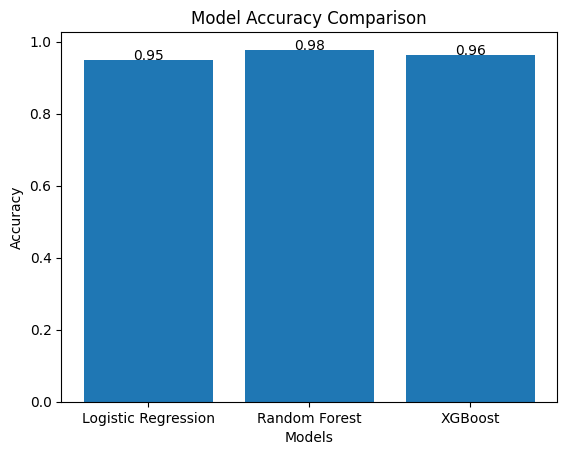

In [8]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, v in enumerate(results.values()):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.show()

<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">9️⃣ BEST MODEL SELECTION</h2>

<p style="color:lightgray;">
Selecting the most accurate model for final prediction
</p>

<hr>

</div>

In [9]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("Best Model:", best_model_name)
print("Accuracy:", results[best_model_name])

Best Model: Random Forest
Accuracy: 0.9779467680608365


<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">🔟 MODEL PREDICTION</h2>

<p style="color:lightgray;">
Using the selected model to predict SMS phishing on test data
</p>

<hr>

</div>

In [10]:
y_pred = best_model.predict(X_test)

<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">1️⃣1️⃣ MODEL EVALUATION (CLASSIFICATION REPORT)</h2>

<p style="color:lightgray;">
Evaluating performance using precision, recall, and F1-score
</p>

<hr>

</div>


In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1045
           1       0.99      0.90      0.94       270

    accuracy                           0.98      1315
   macro avg       0.98      0.95      0.96      1315
weighted avg       0.98      0.98      0.98      1315



<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">1️⃣2️⃣ CONFUSION MATRIX ANALYSIS</h2>

<p style="color:lightgray;">
Analyzing prediction accuracy and errors using confusion matrix
</p>

<hr>

</div>

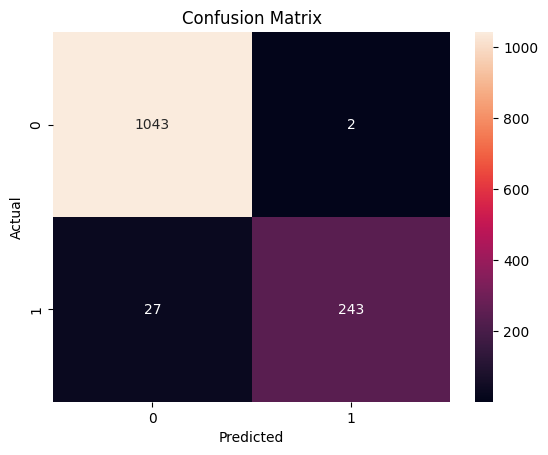

In [12]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">1️⃣3️⃣ MODEL SAVING & DEPLOYMENT READY</h2>

<p style="color:lightgray;">
Saving trained model and TF-IDF vectorizer for real-world use
</p>

<hr>

</div>

In [13]:
model_data = {
    "model": best_model,
    "tfidf": tfidf
}

joblib.dump(model_data, "sms_phishing_model.pkl")

['sms_phishing_model.pkl']

<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">🔄 MODEL LOADING FOR DEPLOYMENT</h2>

<p style="color:lightgray;">
Loading saved model and vectorizer for real-time predictions
</p>

<hr>

</div>


In [14]:
data = joblib.load("sms_phishing_model.pkl")

model = data["model"]
tfidf = data["tfidf"]

<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">✅ FINAL CONCLUSION</h2>

<p style="color:lightgray;">
In this project, we developed a machine learning-based SMS phishing detection system 
using combined datasets from multiple sources to improve robustness and accuracy.
</p>

<p style="color:lightgray;">
After evaluating multiple models, Random Forest achieved the highest accuracy (~97.8%), 
demonstrating strong performance in identifying phishing (smishing) messages.
</p>

<p style="color:lightgray;">
The model shows excellent balance between precision, recall, and F1-score, 
making it reliable for real-world applications.
</p>

<p style="color:lightgray;">
This system can be extended and integrated into mobile applications, 
security tools, or real-time alert systems to prevent phishing attacks.
</p>

<hr>

</div>